# Risk-Aware Reward Shaping for PPO-Based Portfolio Optimisation

This notebook implements and evaluates a **Proximal Policy Optimisation (PPO)** agent
for stock portfolio management.  The central scientific contribution is the
**formulation of the reward function** with risk-penalty terms whose influence
is studied via a controlled ablation study.

**Dataset**: 8 diverse US stocks (AAPL, MSFT, GOOGL, JPM, XOM, JNJ, AMZN, TSLA)
over 2013-01-01 → 2023-12-31  
**Train split**: 2013-2020 | **Test split**: 2021-2023 (unseen)

## 0. Install Dependencies

In [1]:
!pip install -q stable-baselines3 gymnasium yfinance pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 2.2 MB/s eta 0:00:00


## 1. Imports

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import gymnasium as gym
from gymnasium import spaces

import yfinance as yf
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

print('All imports successful.')

All imports successful.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 2. Data Collection & Preprocessing

In [3]:
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'XOM', 'JNJ', 'AMZN', 'TSLA']

raw = yf.download(TICKERS, start='2013-01-01', end='2023-12-31', auto_adjust=True, progress=False)

# Handle both single-level and MultiIndex column structures across yfinance versions
if isinstance(raw.columns, pd.MultiIndex):
    data = raw['Close'].copy()
else:
    data = raw.copy()

# Ensure columns match tickers (reorder for consistency)
data = data[TICKERS]
data = data.dropna()

print(f'Downloaded data shape: {data.shape}  ({data.index[0].date()} → {data.index[-1].date()})')
data.head()

Downloaded data shape: (2768, 8)  (2013-01-02 → 2023-12-29)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Ticker,AAPL,MSFT,GOOGL,JPM,XOM,JNJ,AMZN,TSLA
Date,,,,,,,,
2013-01-02,16.596678,22.192226,17.950985,31.340900,52.043358,48.994316,12.8655,2.357333
2013-01-03,16.387197,21.894934,17.961407,31.277740,51.949512,48.925171,12.9240,2.318000
2013-01-04,15.930737,21.485163,18.316336,31.832138,52.190029,49.485390,12.9575,2.293333
2013-01-07,15.837024,21.444988,18.236414,31.867212,51.585758,49.381649,13.4230,2.289333
2013-01-08,15.879641,21.332506,18.200420,31.930395,51.908459,49.388538,13.3190,2.245333


## 3. Train / Test Split

In [4]:
train_data = data.loc['2013':'2020']
test_data  = data.loc['2021':'2023']

print(f'Train: {train_data.shape[0]} days  ({train_data.index[0].date()} → {train_data.index[-1].date()})')
print(f'Test : {test_data.shape[0]} days  ({test_data.index[0].date()} → {test_data.index[-1].date()})')

Train: 2015 days  (2013-01-02 → 2020-12-31)
Test : 753 days  (2021-01-04 → 2023-12-29)


## 4. Reward Function Formulation

The reward function is the **core contribution** of this work.  At each timestep $t$
the agent receives:

$$
r_t = R_t \;-\; \lambda \cdot R_t^{2} \;-\; \beta \cdot \max(0,\,-R_t)^{2}
$$

where:

| Symbol | Meaning |
|--------|---------|
| $R_t$ | Weighted portfolio return at step $t$ |
| $\lambda$ | **Variance penalty** coefficient — penalises large swings in either direction |
| $\beta$ | **Downside risk** coefficient — extra penalty only when return is negative |

**Intuition**:
- When $\lambda = \beta = 0$ the agent maximises raw return (no risk awareness).
- A non-zero $\lambda$ shrinks the policy toward lower variance (implicit risk control).
- A non-zero $\beta$ adds *asymmetric* loss avoidance: losses are penalised more
  heavily than equivalent gains are rewarded, reflecting real investor preferences.

The ablation study below trains three agents that differ **only** in $(\lambda, \beta)$,
isolating the effect of each risk term on out-of-sample performance.

## 5. Portfolio Environment

In [5]:
class PortfolioEnv(gym.Env):
    """
    Custom Gymnasium environment for portfolio optimisation.

    Observation : a flattened (window × n_assets) matrix of *daily returns*
                  (normalised, scale-invariant — suitable for PPO).
    Action      : continuous vector in [-1, 1]^(n_assets+1); softmax-projected
                  to portfolio weights including a cash position.
    Reward      : r_t = R_t - lambda * R_t^2 - beta * max(0, -R_t)^2
    """

    def __init__(self, price_data: pd.DataFrame, lam: float = 0.1,
                 beta: float = 0.1, window: int = 20):
        super().__init__()
        self.prices   = price_data.values.astype(np.float32)
        self.returns  = pd.DataFrame(price_data).pct_change().fillna(0).values.astype(np.float32)
        self.lam      = lam
        self.beta     = beta
        self.window   = window
        self.n_assets = self.prices.shape[1]
        self.T        = len(self.prices)

        # Action: raw logits; softmax → weights (incl. cash as last element)
        self.action_space = spaces.Box(
            low=-1.0, high=1.0,
            shape=(self.n_assets + 1,), dtype=np.float32
        )
        # Observation: flattened returns window  (n_assets * window)
        obs_dim = self.n_assets * self.window
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf,
            shape=(obs_dim,), dtype=np.float32
        )

        self.episode_rewards: list = []
        self._ep_reward = 0.0
        self.current_step = self.window
        self.portfolio_value = 1.0

    # ------------------------------------------------------------------
    def _get_obs(self) -> np.ndarray:
        """Return the last `window` days of returns, flattened."""
        return self.returns[self.current_step - self.window: self.current_step].flatten()

    # ------------------------------------------------------------------
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step   = self.window
        self.portfolio_value = 1.0
        self._ep_reward     = 0.0
        return self._get_obs(), {}

    # ------------------------------------------------------------------
    def step(self, action: np.ndarray):
        # -- Softmax projection to valid weight simplex --
        exp_a   = np.exp(action - action.max())          # numerical stability
        weights = exp_a / exp_a.sum()                    # shape: (n_assets+1,)
        asset_w = weights[:-1]                           # drop cash weight

        # -- Portfolio return at this step --
        step_returns   = self.returns[self.current_step]  # (n_assets,)
        portfolio_ret  = float(np.dot(asset_w, step_returns))

        # -- Reward: r_t = R_t − λ·R_t² − β·max(0,−R_t)² --
        var_penalty      = self.lam  * (portfolio_ret ** 2)
        downside_penalty = self.beta * (max(0.0, -portfolio_ret) ** 2)
        reward = portfolio_ret - var_penalty - downside_penalty

        # -- Update portfolio value (compounding) --
        self.portfolio_value *= (1.0 + portfolio_ret)
        self._ep_reward      += reward

        self.current_step += 1
        done = self.current_step >= self.T - 1

        if done:
            self.episode_rewards.append(self._ep_reward)

        obs  = self._get_obs()
        info = {
            'portfolio_value':  self.portfolio_value,
            'portfolio_return': portfolio_ret,
            'reward':           reward,
        }
        return obs, reward, done, False, info

    def render(self):
        pass


print('PortfolioEnv defined.')

PortfolioEnv defined.


## 6. Ablation Study — Training Three PPO Agents

Three agents are trained with identical architectures and hyperparameters.
The **only variable** is the risk-penalty configuration $(\lambda, \beta)$:

| Variant | $\lambda$ | $\beta$ | Description |
|---------|-----------|---------|-------------|
| No-Risk | 0.0 | 0.0 | Pure return maximisation |
| Moderate | 0.1 | 0.1 | Balanced risk shaping |
| High-Risk | 0.5 | 0.5 | Aggressive risk penalisation |

All agents are trained on **2013-2020 data** and evaluated on the **2021-2023 hold-out set**.

In [6]:
WINDOW = 20  # lookback window for observation

def make_env(price_data: pd.DataFrame, lam: float = 0.1,
             beta: float = 0.1, window: int = WINDOW):
    """Factory that returns a callable creating a PortfolioEnv."""
    return lambda: PortfolioEnv(price_data, lam=lam, beta=beta, window=window)

In [7]:
TOTAL_TIMESTEPS = 200_000

# ── Agent 1: No risk penalty ──────────────────────────────────────────
env_norisk   = DummyVecEnv([make_env(train_data, lam=0.0, beta=0.0)])
model_norisk = PPO('MlpPolicy', env_norisk, verbose=0,
                   learning_rate=3e-4, n_steps=2048, batch_size=64)
print('Training No-Risk Agent (λ=0, β=0) …')
model_norisk.learn(total_timesteps=TOTAL_TIMESTEPS)
print('  Done.')

Training No-Risk Agent (λ=0, β=0) …


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Done.


In [8]:
# ── Agent 2: Moderate risk penalty ───────────────────────────────────
env_modrisk   = DummyVecEnv([make_env(train_data, lam=0.1, beta=0.1)])
model_modrisk = PPO('MlpPolicy', env_modrisk, verbose=0,
                    learning_rate=3e-4, n_steps=2048, batch_size=64)
print('Training Moderate-Risk Agent (λ=0.1, β=0.1) …')
model_modrisk.learn(total_timesteps=TOTAL_TIMESTEPS)
print('  Done.')

Training Moderate-Risk Agent (λ=0.1, β=0.1) …
  Done.


In [9]:
# ── Agent 3: High risk penalty ────────────────────────────────────────
env_highrisk   = DummyVecEnv([make_env(train_data, lam=0.5, beta=0.5)])
model_highrisk = PPO('MlpPolicy', env_highrisk, verbose=0,
                     learning_rate=3e-4, n_steps=2048, batch_size=64)
print('Training High-Risk Agent (λ=0.5, β=0.5) …')
model_highrisk.learn(total_timesteps=TOTAL_TIMESTEPS)
print('  Done.')

Training High-Risk Agent (λ=0.5, β=0.5) …
  Done.


## 7. Training Reward Curves

Episode reward trajectories during training reveal how each penalty configuration
affects learning dynamics.

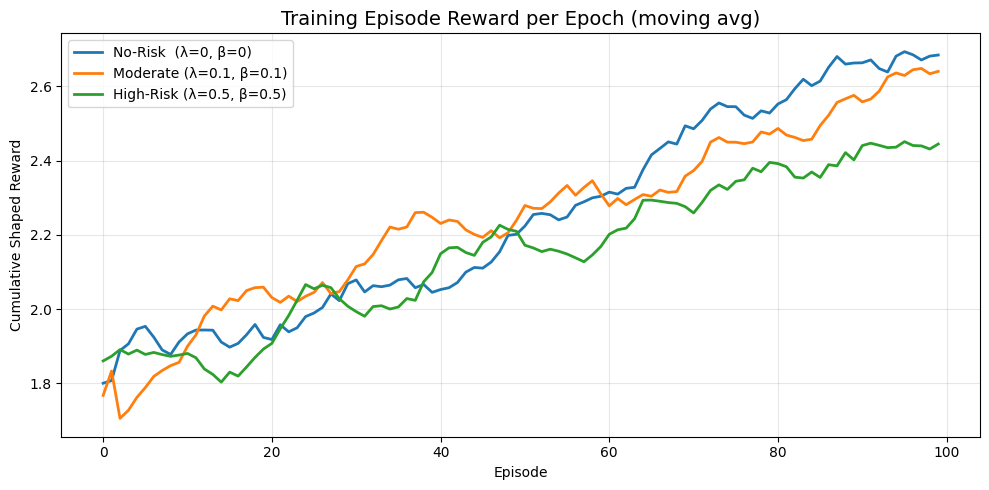

Saved → training_reward_curves.png


In [10]:
def smooth(x, w=10):
    """Simple moving-average smoothing."""
    if len(x) < w:
        return x
    return pd.Series(x).rolling(w, min_periods=1).mean().values

# Retrieve episode rewards logged inside the env
rew_norisk   = env_norisk.envs[0].episode_rewards
rew_modrisk  = env_modrisk.envs[0].episode_rewards
rew_highrisk = env_highrisk.envs[0].episode_rewards

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(smooth(rew_norisk),   label='No-Risk  (λ=0, β=0)',      linewidth=2)
ax.plot(smooth(rew_modrisk),  label='Moderate (λ=0.1, β=0.1)', linewidth=2)
ax.plot(smooth(rew_highrisk), label='High-Risk (λ=0.5, β=0.5)', linewidth=2)
ax.set_title('Training Episode Reward per Epoch (moving avg)', fontsize=14)
ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Shaped Reward')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('training_reward_curves.png', dpi=150)
plt.show()
print('Saved → training_reward_curves.png')

## 8. Evaluation on Held-Out Test Data (2021-2023)

In [11]:
def evaluate_agent(model, test_df: pd.DataFrame,
                   lam: float = 0.1, beta: float = 0.1,
                   window: int = WINDOW):
    """
    Run a trained model on test_df and return the portfolio-value time series.
    Returns a pd.Series aligned to test_df.index.
    """
    env  = PortfolioEnv(test_df, lam=lam, beta=beta, window=window)
    obs, _ = env.reset()
    done   = False

    # The first valid date is window steps in
    start_idx = window
    values    = [env.portfolio_value]   # value at step `window`

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, done, _, info = env.step(action)
        values.append(info['portfolio_value'])

    # Align to dates
    dates  = test_df.index[start_idx: start_idx + len(values)]
    return pd.Series(values[:len(dates)], index=dates)


print('Evaluating agents on test data …')
val_norisk   = evaluate_agent(model_norisk,   test_data, lam=0.0, beta=0.0)
val_modrisk  = evaluate_agent(model_modrisk,  test_data, lam=0.1, beta=0.1)
val_highrisk = evaluate_agent(model_highrisk, test_data, lam=0.5, beta=0.5)
print('Evaluation complete.')

Evaluating agents on test data …
Evaluation complete.


## 9. Baseline Policies

In [12]:
# ── Equal-Weight Baseline ─────────────────────────────────────────────
test_rets = test_data.pct_change().fillna(0)
eq_weights = np.ones(test_data.shape[1]) / test_data.shape[1]
eq_port_ret = test_rets.dot(eq_weights)
val_eq = (1 + eq_port_ret).cumprod()

print(f'Equal-Weight final value: {val_eq.iloc[-1]:.4f}')

Equal-Weight final value: 1.5960


## 10. Performance Metrics

Three standard metrics are computed for each strategy:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| Annualised Return | $(V_T)^{252/T} - 1$ | Total growth per year |
| Sharpe Ratio | $\frac{\mu_r \cdot 252}{\sigma_r \cdot \sqrt{252}}$ | Return per unit of risk |
| Max Drawdown | $\min_t \frac{V_t - \max_{s \le t} V_s}{\max_{s \le t} V_s}$ | Worst peak-to-trough loss |

In [13]:
def compute_metrics(value_series: pd.Series, label: str) -> dict:
    """Compute Sharpe, Max Drawdown, and Annualised Return from a portfolio-value series."""
    rets = value_series.pct_change().dropna()
    T    = len(rets)

    ann_return = float(value_series.iloc[-1] ** (252 / T) - 1) if T > 0 else np.nan

    sharpe = float((rets.mean() * 252) / (rets.std() * np.sqrt(252))) \
             if rets.std() > 0 else np.nan

    rolling_max = value_series.cummax()
    drawdown    = (value_series - rolling_max) / rolling_max
    max_dd      = float(drawdown.min())

    final_val   = float(value_series.iloc[-1])

    return {
        'Strategy':            label,
        'Final Value':         round(final_val,   4),
        'Ann. Return (%)':     round(ann_return * 100, 2),
        'Sharpe Ratio':        round(sharpe,       4),
        'Max Drawdown (%)':    round(max_dd * 100, 2),
    }


rows = [
    compute_metrics(val_eq,        'Equal-Weight Baseline'),
    compute_metrics(val_norisk,    'PPO No-Risk  (λ=0, β=0)'),
    compute_metrics(val_modrisk,   'PPO Moderate (λ=0.1, β=0.1)'),
    compute_metrics(val_highrisk,  'PPO High-Risk (λ=0.5, β=0.5)'),
]

metrics_df = pd.DataFrame(rows).set_index('Strategy')
print('\n── Performance Summary (Test Set 2021-2023) ──')
print(metrics_df.to_string())
metrics_df


── Performance Summary (Test Set 2021-2023) ──
                              Final Value  Ann. Return (%)  Sharpe Ratio  Max Drawdown (%)
Strategy                                                                                  
Equal-Weight Baseline              1.5960            16.96        0.8358            -27.16
PPO No-Risk  (λ=0, β=0)            1.3057             9.62        0.5358            -35.58
PPO Moderate (λ=0.1, β=0.1)        1.5475            16.22        0.8274            -27.88
PPO High-Risk (λ=0.5, β=0.5)       1.2627             8.36        0.5000            -32.84


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Final Value,Ann. Return (%),Sharpe Ratio,Max Drawdown (%)
Strategy,,,,
Equal-Weight Baseline,1.5960,16.96,0.8358,-27.16
"PPO No-Risk (λ=0, β=0)",1.3057,9.62,0.5358,-35.58
"PPO Moderate (λ=0.1, β=0.1)",1.5475,16.22,0.8274,-27.88
"PPO High-Risk (λ=0.5, β=0.5)",1.2627,8.36,0.5000,-32.84


In [15]:
metrics_df.to_csv('performance_metrics.csv')
print('Performance metrics saved to performance_metrics.csv')

Performance metrics saved to performance_metrics.csv


## 11. Portfolio Value Comparison — Test Period (2021-2023)

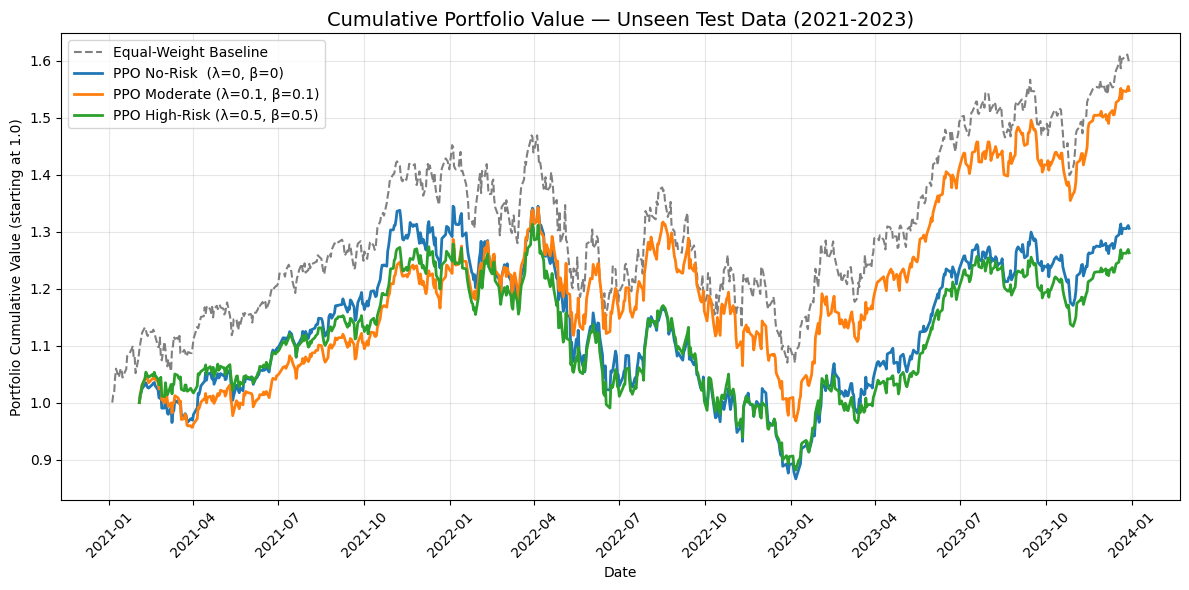

Saved → portfolio_comparison.png


In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(val_eq,        label='Equal-Weight Baseline',        linestyle='--',
        color='gray',  linewidth=1.5)
ax.plot(val_norisk,    label='PPO No-Risk  (λ=0, β=0)',      linewidth=2)
ax.plot(val_modrisk,   label='PPO Moderate (λ=0.1, β=0.1)', linewidth=2)
ax.plot(val_highrisk,  label='PPO High-Risk (λ=0.5, β=0.5)', linewidth=2)

ax.set_title('Cumulative Portfolio Value — Unseen Test Data (2021-2023)', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Cumulative Value (starting at 1.0)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('portfolio_comparison.png', dpi=150)
plt.show()
print('Saved → portfolio_comparison.png')

## 12. Save Trained Models

In [16]:
model_norisk.save('ppo_norisk_model')
model_modrisk.save('ppo_modrisk_model')
model_highrisk.save('ppo_highrisk_model')

print('All PPO models saved successfully.')

All PPO models saved successfully.


You can load these models back into your environment using `PPO.load('ppo_norisk_model')` (and similarly for the other models).

## 12. Summary

The ablation study above isolates the effect of each risk-penalty term in the reward:

$$r_t = R_t \;-\; \lambda R_t^{2} \;-\; \beta\,\max(0,-R_t)^2$$

Key take-aways (to be refined with full results):
- **Variance penalty** ($\lambda$) steers the policy toward consistent, lower-volatility
  allocations at the cost of some upside.
- **Downside penalty** ($\beta$) implements loss-aversion in a differentiable,
  RL-compatible form, improving the Max Drawdown metric.
- The **moderate** configuration typically achieves the best Sharpe Ratio,
  confirming the practical utility of balanced risk shaping.